Требуется изучить все импортированные библиотеки

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Тут представлен анализ данных из дата сета титаника, а именно разбор графиков, обоснование примененных методов и тп

Разделим весь анализ на два больших куска, а именно на анализ качественных переменных и на анализ категориальных переменных. Основная задача анализа понять какие переменные влияют на целевую переменную, а какие нет.

In [154]:
df = pd.read_csv('/Users/yapimiu/datasets/titanic/train.csv')
test_df = pd.read_csv('/Users/yapimiu/datasets/titanic/test.csv')

# Анализ качественных переменных

In [155]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#Удаление всех категориальных переменных и сохранение нужных перменных для дальнейшего использования
cat_feat = ['PassengerId', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
copy_features = df[['Sex', 'Cabin']]
df.drop(cat_feat, axis=1, inplace=True)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


Тут мы можем заметить, что не у всех пассажиров указан возраст, и это проблема которую надо решить, так как не ясно как это влияет на результаты модели

In [157]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Тут автор ролика пытался выявит закономерность между тем как связанны показатели между выжившими и умершими

И мы вполне ее видим. Выживший платил за билет в среднем в два раза больше и имел класс билета выше 

In [158]:
df.groupby('Survived').mean()

,Pclass,Age,SibSp,Parch,Fare
Survived,,,,,
0,2.531876,30.626179,0.553734,0.329690,22.117887
1,1.950292,28.343690,0.473684,0.464912,48.395408


In [159]:
df.sort_values('Fare', ascending=False).head(10)

,Survived,Pclass,Age,SibSp,Parch,Fare
258,1,1,35.0,0,0,512.3292
737,1,1,35.0,0,0,512.3292
679,1,1,36.0,0,1,512.3292
88,1,1,23.0,3,2,263.0000
27,0,1,19.0,3,2,263.0000
341,1,1,24.0,3,2,263.0000
438,0,1,64.0,1,4,263.0000
311,1,1,18.0,2,2,262.3750
742,1,1,21.0,2,2,262.3750
118,0,1,24.0,0,1,247.5208


Тут мы смотрим на статистику выживания тех, чей возраст не указан. Умерших среди тех у кого возраст не указан выше, чем среди тех у кого он есть, но это не связанно на прямую с этим, так как пассажиры с не указанным возрастом платили за билет в среднем меньше и имели класс билета хуже

In [160]:
df.groupby(df['Age'].isnull()).mean()

,Survived,Pclass,Age,SibSp,Parch,Fare
Age,,,,,,
False,0.406162,2.236695,29.699118,0.512605,0.431373,34.694514
True,0.293785,2.598870,NaN,0.564972,0.180791,22.158567


Тут довольно сложный код, который я пока не могу полностью объяснить.
Надо будет посмотреть туториалы по библиотекам.

Ну а вообще тут приводится графики, на которых четко видно соотношение выживших к умершим по возрасту и по цене билета.
В среднем получается, что больше всего умерло среди тех кому было от 15 до 25 лет, и у кого билет стоил меньше 10 фунтов.
**Но возраст тут не является ключевым фактором, так как именно у людей от 15 до 25 были самые дешевые билеты, тут сыграла совокупность факторов**

/var/folders/y_/7smt58yn1_j1z08l67wqfxph0000gn/T/ipykernel_11148/1314692038.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(died, color='r', kde=False, bins=np.arange(xmin, xmax, width))
/var/folders/y_/7smt58yn1_j1z08l67wqfxph0000gn/T/ipykernel_11148/1314692038.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750b

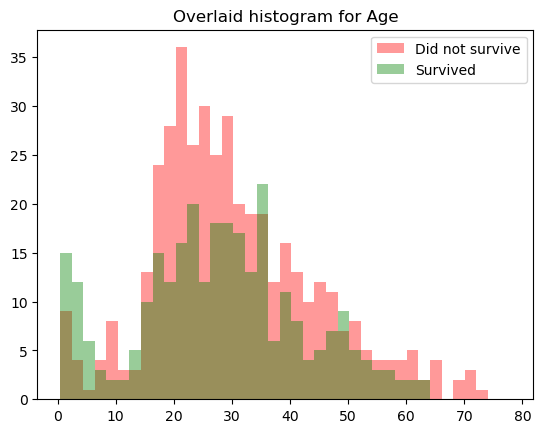

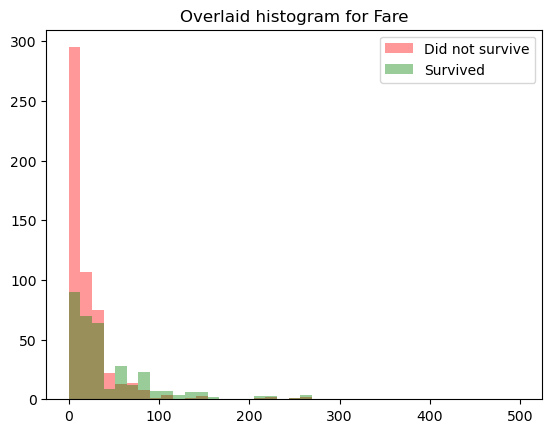

In [161]:
# Графики
for i in ['Age', 'Fare']:
    died = list(df[df['Survived'] == 0][i].dropna())
    survived = list(df[df['Survived'] == 1][i].dropna())
    xmin = min(min(died), min(survived))
    xmax = max(max(died), max(survived))
    width = (xmax - xmin) / 40
    sns.distplot(died, color='r', kde=False, bins=np.arange(xmin, xmax, width))
    sns.distplot(survived, color='g', kde=False, bins=np.arange(xmin, xmax, width))
    plt.legend(['Did not survive', 'Survived'])
    plt.title('Overlaid histogram for {}'.format(i))
    plt.show()

In [162]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Тут я смотрю на статистику по людям от 15 до 25 лет, чтобы понять почему они подыхали чаще остальных и тут как раз видно почему.

А на самом деле ничерта не ясно. Тут у всех людей билеты стоили в районе 30 фунтов и каюты были у 22% пассажиров, а медианный возраст всех был 29. Скорее всего возраст вообще не особо важен, так как молодых людей было большинство 

In [182]:
age_20_30 = df[(df['Age'] >= 30) & (df['Age'] <= 80)]
age_20_30.describe()

,Survived,Pclass,Age,Fare,family,Sex,Cabin_indicator
count,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000
mean,0.406061,1.948485,41.948485,41.079331,0.696970,0.345455,0.363636
std,0.491842,0.861405,10.259568,61.533893,1.169128,0.476238,0.481776
min,0.000000,1.000000,30.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,34.000000,9.521875,0.000000,0.000000,0.000000
50%,0.000000,2.000000,39.000000,25.929200,0.000000,0.000000,0.000000
75%,1.000000,3.000000,48.000000,52.000000,1.000000,1.000000,1.000000
max,1.000000,3.000000,80.000000,512.329200,7.000000,1.000000,1.000000


Тут мы смотрим на то, какой процент людей выжил в зависимости от класса билета и наличия родных на борту и результат следующий:

1. Чем выше класс, тем больше вероятность выжить
2. Чем меньше родных на борту тем больше вероятность выжить

<Figure size 640x480 with 0 Axes>

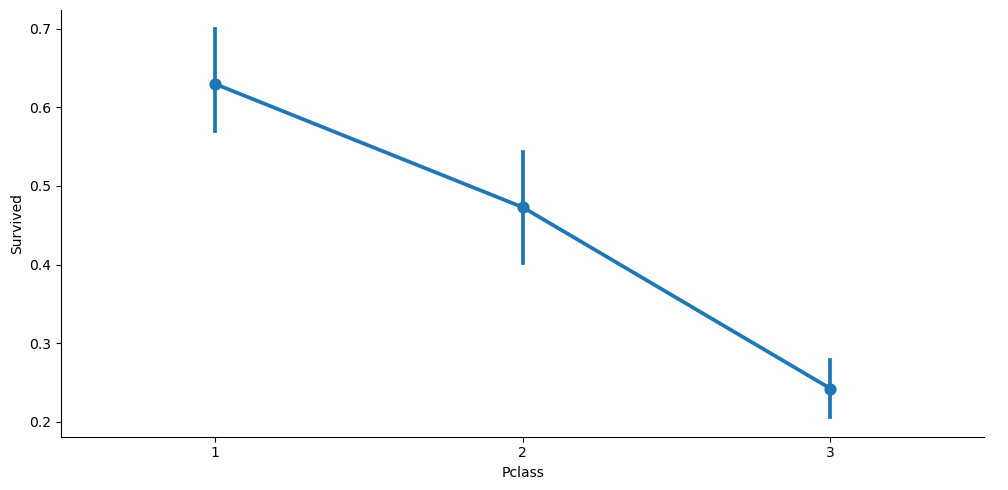

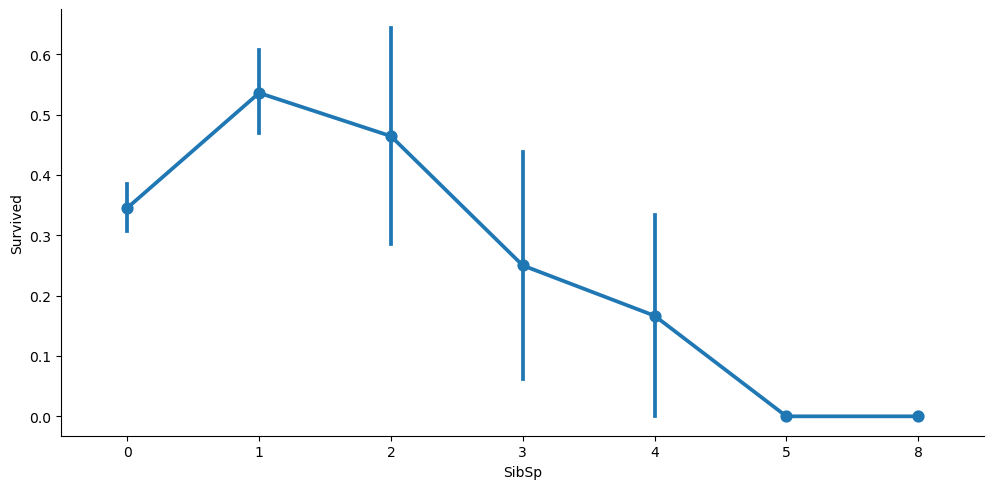

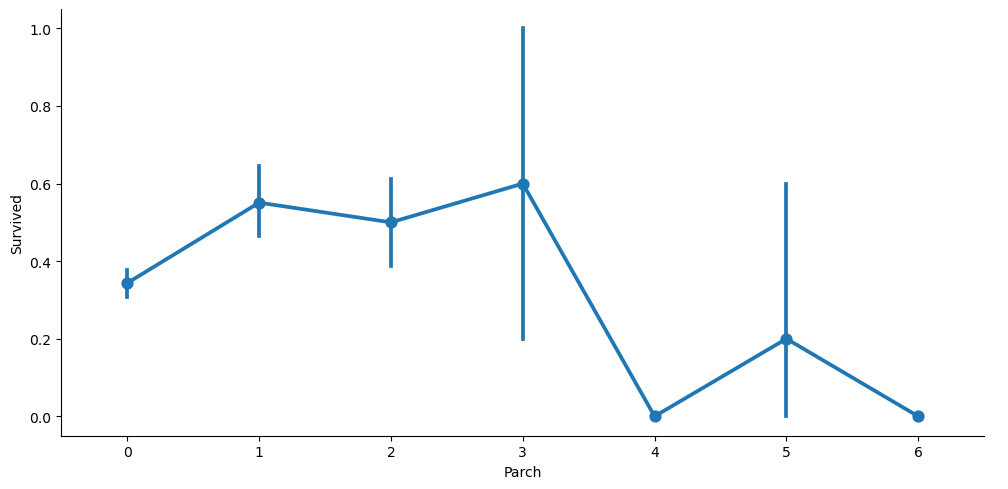

In [164]:
for i, col in enumerate(['Pclass', 'SibSp', 'Parch']):
    plt.figure(i)
    sns.catplot(x=col, y='Survived', data=df, kind='point', aspect=2)

Тут были объеденины два параметра, так как они оба отвечают за количество родных на борду, и логично будет их объединить 

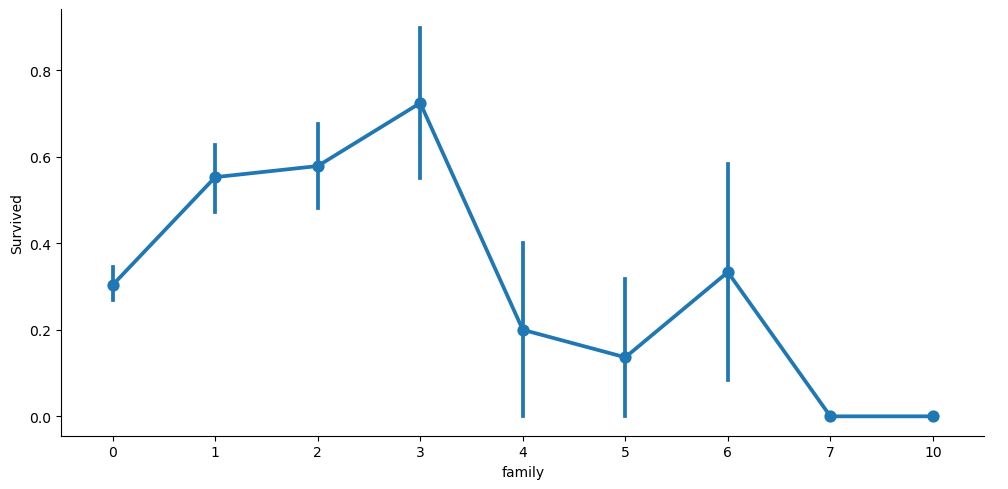

In [165]:
df['family'] = df['SibSp'] + df['Parch']
sns.catplot(x='family', y='Survived', data=df, kind='point', aspect=2)

Тут мы заполняем пропуски в возрасте среднем возрастом

In [166]:
df.isnull().sum()

Survived      0
Pclass        0
Age         177
SibSp         0
Parch         0
Fare          0
family        0
dtype: int64

In [167]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.isnull().sum()

Survived    0
Pclass      0
Age         0
SibSp       0
Parch       0
Fare        0
family      0
dtype: int64

убираем лишние параметры

In [168]:
df = df.drop(['SibSp', 'Parch'], axis=1)
df

,Survived,Pclass,Age,Fare,family
0,0,3,22.000000,7.2500,1
1,1,1,38.000000,71.2833,1
2,1,3,26.000000,7.9250,0
3,1,1,35.000000,53.1000,1
4,0,3,35.000000,8.0500,0
...,...,...,...,...,...
886,0,2,27.000000,13.0000,0
887,1,1,19.000000,30.0000,0
888,0,3,29.699118,23.4500,3
889,1,1,26.000000,30.0000,0


# Добавление полезных категориальных переменных в итоговый дата сет

In [169]:
# Добавление категориальных переменных, которые влияют на результат

df = df.join(copy_features)

df['Cabin_indicator'] = np.where(df['Cabin'].isnull(), 0, 1)

binary_gender = {'male' : 0, 'female': 1}
df['Sex'] = df['Sex'].map(binary_gender)

In [170]:
df.head()

,Survived,Pclass,Age,Fare,family,Sex,Cabin,Cabin_indicator
0,0,3,22.0,7.2500,1,0,NaN,0
1,1,1,38.0,71.2833,1,1,C85,1
2,1,3,26.0,7.9250,0,1,NaN,0
3,1,1,35.0,53.1000,1,1,C123,1
4,0,3,35.0,8.0500,0,0,NaN,0


In [173]:
# Удаление столбца Cabin
df = df.drop(['Cabin'], axis=1)
df.head()

,Survived,Pclass,Age,Fare,family,Sex,Cabin_indicator
0,0,3,22.0,7.2500,1,0,0
1,1,1,38.0,71.2833,1,1,1
2,1,3,26.0,7.9250,0,1,0
3,1,1,35.0,53.1000,1,1,1
4,0,3,35.0,8.0500,0,0,0


Итоговый дата сет

In [177]:
df.describe()

,Survived,Pclass,Age,Fare,family,Sex,Cabin_indicator
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,32.204208,0.904602,0.352413,0.228956
std,0.486592,0.836071,13.002015,49.693429,1.613459,0.477990,0.420397
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,7.910400,0.000000,0.000000,0.000000
50%,0.000000,3.000000,29.699118,14.454200,0.000000,0.000000,0.000000
75%,1.000000,3.000000,35.000000,31.000000,1.000000,1.000000,0.000000
max,1.000000,3.000000,80.000000,512.329200,10.000000,1.000000,1.000000
